# SEM Surface Porosity — Pore Overlays

Translucent sky-blue pore overlays for the ALG/GUM, PVA/GUM and A40G40P20 SEM series, using the hybrid Otsu + absolute-darkness segmentation in `sem_porosity/quantify.py`. Reproduces `sem_porosity/output/overlay_*.png`.

In [1]:
import os
import matplotlib.pyplot as plt
from sem_porosity.quantify import pore_overlay

IMG, IMG1 = 'sem_porosity/images', 'sem_porosity/images_figs1'
OUT = 'sem_porosity/output'
os.makedirs(OUT, exist_ok=True)

# (label, path, per-series segmentation params)
CONFIGS = [
    # ALG/GUM series: dark_floor 60, min_hole 30; alg80/alg60 use a looser min-area
    ('alg80_gum20', f'{IMG}/sem_alg80_gum20.tif', dict(dark_floor=60, min_pore_area=8,  min_hole_area=30)),
    ('alg60_gum40', f'{IMG}/sem_alg60_gum40.tif', dict(dark_floor=60, min_pore_area=8,  min_hole_area=30)),
    ('alg20_gum80', f'{IMG}/sem_alg20_gum80.tif', dict(dark_floor=60, min_pore_area=30, min_hole_area=30)),
    # PVA/GUM series: dark_floor 40, min_pore 40 + shape filter (reject scratches)
    ('pva80_gum20', f'{IMG}/sem_pva80_gum20.tif', dict(dark_floor=40, min_pore_area=40, min_hole_area=30, shape_filter=(3.5, 0.55))),
    ('pva60_gum40', f'{IMG}/sem_pva60_gum40.tif', dict(dark_floor=40, min_pore_area=40, min_hole_area=30, shape_filter=(3.5, 0.55))),
    ('pva20_gum80', f'{IMG}/sem_pva20_gum80.tif', dict(dark_floor=40, min_pore_area=40, min_hole_area=30, shape_filter=(3.5, 0.55))),
    # A40G40P20 (figs1) series: dark_floor 60, min_pore/min_hole 180, crop info banner
    ('A40G40P20_ML15', f'{IMG1}/A40G40P20_ML15_100x.tif',     dict(dark_floor=60, min_pore_area=180, min_hole_area=180, crop_top=896)),
    ('A40G40P20_ML20', f'{IMG1}/A40G40P20_ML20_100x_q02.tif', dict(dark_floor=60, min_pore_area=180, min_hole_area=180, crop_top=896)),
]

overlays = {}
for label, path, params in CONFIGS:
    overlay, porosity = pore_overlay(path, **params)
    plt.imsave(f'{OUT}/overlay_{label}.png', overlay)
    overlays[label] = (overlay, porosity)
    print(f'overlay_{label}.png  porosity={porosity:.2f}%')

overlay_alg80_gum20.png  porosity=41.54%
overlay_alg60_gum40.png  porosity=5.70%


overlay_alg20_gum80.png  porosity=0.00%
overlay_pva80_gum20.png  porosity=0.00%


overlay_pva60_gum40.png  porosity=0.11%


overlay_pva20_gum80.png  porosity=7.87%


overlay_A40G40P20_ML15.png  porosity=6.21%


overlay_A40G40P20_ML20.png  porosity=17.67%


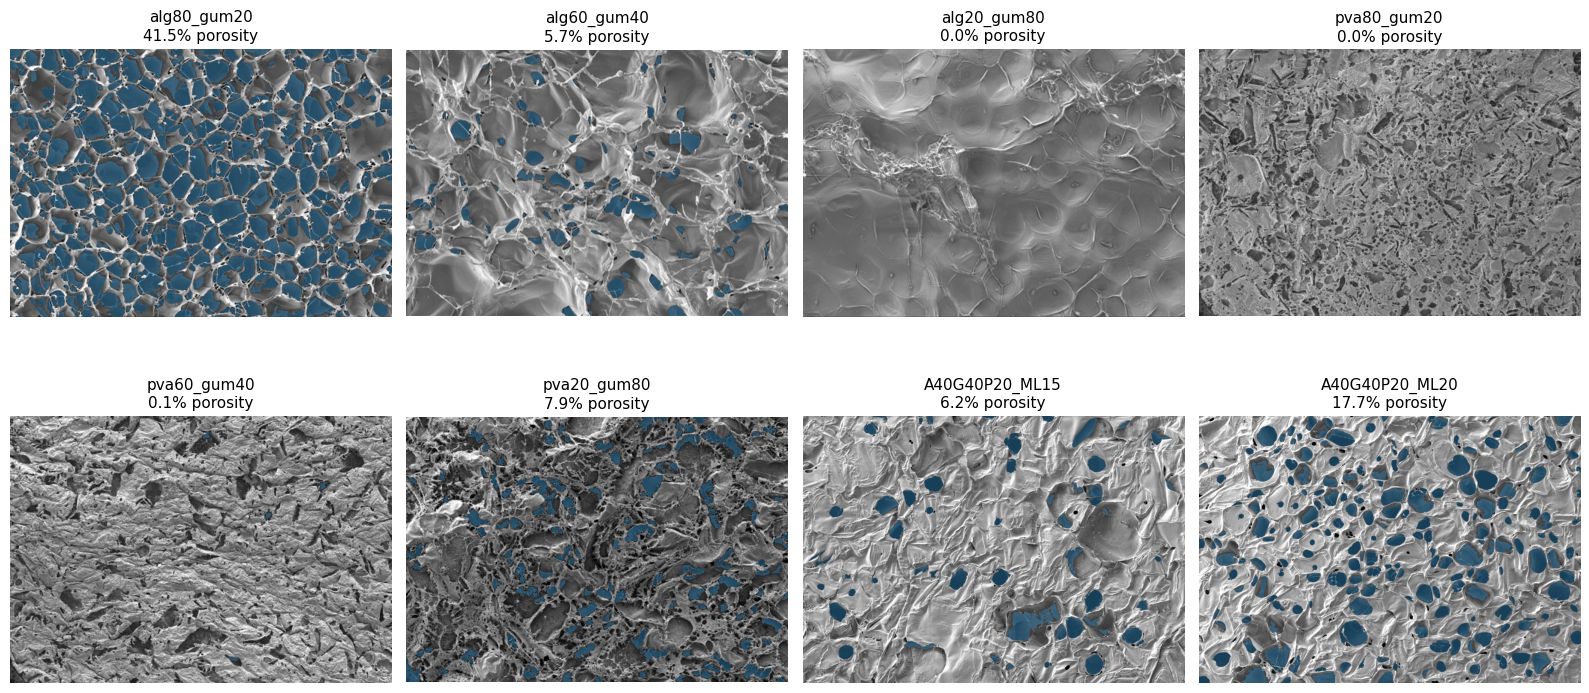

In [2]:
# Display all overlays
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (label, _p, _params) in zip(axes.ravel(), CONFIGS):
    overlay, porosity = overlays[label]
    ax.imshow(overlay)
    ax.set_title(f'{label}\n{porosity:.1f}% porosity', fontsize=11)
    ax.axis('off')
fig.tight_layout()
plt.show()